# NumCompute Streaming Demo

This notebook demonstrates the NumCompute toolkit as an end-to-end scientific computing and lightweight ML workflow across different datasets also by building a decision tree–based machine learning framework that supports both: Streaming Learning and Model Ensembling.

We cover:
- CSV loading using `io.py`
- Missing value inspection and imputation
- Preprocessing using `preprocessing.py`
- Train-test split using `utils.py`
- Pipeline chaining using `pipeline.py`
- Estimator protocol using `models.py`
- Metrics evaluation using `metrics.py`
- Sorting, searching, top-k, quickselect, ranking, and percentiles
- Descriptive statistics and axis-wise behaviour
- Finite-difference gradient and Jacobian estimation
- Benchmarking loop-based vs vectorised implementations with timing and memory usage
- Splitting the dataset into chunks to simulate streaming
- Incremental training using `.partial_fit()`
- Logging and visualising chunk-wise metrics
- Comparing a streaming decision tree with a streaming ensemble


## 1. Loading the required libraries

The notebook is stored inside the `demo/` folder, so we add the project root to `sys.path` before importing `numcompute`.


In [13]:
# Standard library imports
import os
import sys
import csv
import time

# Go up until we find the folder that contains numcompute_stream

BASE_DIR = os.path.abspath(os.getcwd())
# Add project root to Python path so that numcompute can be imported from demo/
while not os.path.exists(os.path.join(BASE_DIR, "numcompute_stream")):
    parent = os.path.dirname(BASE_DIR)

    if parent == BASE_DIR:
        raise FileNotFoundError(
            "Could not find 'numcompute_stream' in this directory or any parent directory."
        )

    BASE_DIR = parent
sys.path.insert(0, BASE_DIR)


print("Using BASE_DIR:", BASE_DIR)
print("Stream exists:", os.path.exists(os.path.join(BASE_DIR, "numcompute_stream")))





# NumPy and matplotlib are allowed by the assignment
import numpy as np
import matplotlib.pyplot as plt

# NumCompute_stream modules
from numcompute_stream.io import read_csv
from numcompute_stream.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, ColumnTransformer, Imputer
from numcompute_stream.sort_search import sort, topk, quickselect, binary_search
from numcompute_stream.rank import rank, percentile
from numcompute_stream.stats import mean, median, variance, std, minimum, maximum, histogram, quantiles, describe
from numcompute_stream.optim import grad, jacobian
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.models import ZeroRClassifier, ZeroRRegressor
from numcompute_stream.metrics import accuracy, precision, recall, f1, mse, rmse, mad, mape, confusion_matrix, roc_curve, auc
from numcompute_stream.utils import train_test_split
from numcompute_stream.benchmarking import run_benchmarks
#from numcompute_stream.stream import StreamTrainer
#from numcompute_stream.io import load_dataset_csv
from numcompute_stream.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    ColumnTransformer,
    Imputer
)
#from numcompute_stream.preprocessing import SimpleImputer, StandardScaler
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.tree import StreamingDecisionTreeClassifier
#from numcompute_stream.ensemble import RandomForestClassifier
#from numcompute_stream.stream import StreamTrainer
#from numcompute_stream.metrics import Accuracy
#from numcompute_stream.visualise import (
    #plot_metric_over_time,
    #compare_models,
    #plot_predictions_vs_ground_truth,
#)

print("Imports completed successfully.")
print("Project root:", BASE_DIR)





Using BASE_DIR: c:\Users\sanza\programming_task_2
Stream exists: True
Imports completed successfully.
Project root: c:\Users\sanza\programming_task_2


## 2. Environment notes

These details support reproducibility of the demo and benchmarking results.


In [14]:
import sys
import os
import numpy as np

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Current working directory:", os.getcwd())

Python version: 3.13.9
NumPy version: 2.3.5
Current working directory: c:\Users\sanza\programming_task_2\demo


## 3. Loading datasets using `io.py`

We load all datasets using the custom `read_csv()` function from `io.py`.  
The first row contains headers, so we remove it after loading. Header removal is done here, not inside `io.py`, so the I/O module remains dataset-agnostic.

Dataset roles:
- **Iris**: multi-class classification
- **WineQT**: regression using quality score as target
- **Sleep**: multi-class classification using sleep disorder type as target


In [15]:
# Dictionary of dataset names mapped to their file paths.
# Notes:
# - Iris: multi-class classification
# - WineQT: if you are using DecisionTreeClassifier / RandomForestClassifier only,
#   treat this as classification unless you have also implemented regression trees
# - Sleep: multi-class classification
datasets = {
    "Iris": {
        "path": os.path.join(BASE_DIR, "data", "Iris.csv"),
        "target_col": -1,
        "task": "classification",
    }, # multi-class classification
    "WineQT": {
        "path": os.path.join(BASE_DIR, "data", "WineQT.csv"),
        "target_col": -1,
        "task": "classification",  # DecisionTreeClassifier / RandomForestClassifier
    },
    "Sleep": {
        "path": os.path.join(BASE_DIR, "data", "sleep_data.csv"),
        "target_col": -1,
        "task": "classification",
    }   # multi-class classification
}

# Container for loaded datasets and metadata
data_dict = {}

# Loading each dataset using the custom io.py reader
for name, meta in datasets.items():
    raw_data = read_csv(meta["path"])

    # Assumption:
    # read_csv(path) returns the header row as the first row.
    # If read_csv already skips headers, remove the next two lines
    # and set: header = None ; data = raw_data
    header = raw_data[0]
    data = raw_data[1:]

    # Storing both data and metadata for later pipeline/model usage
    data_dict[name] = {
        "header": header,
        "data": data,
        "target_col": meta["target_col"],
        "task": meta["task"],
        "path": meta["path"],
    }

    print(f"\n{name} Dataset:")
    print("Path:", meta["path"])
    print("Task:", meta["task"])
    print("Shape:", data.shape)
    print("First 5 column names:", header[:5])
    print("Sample first 5 rows and first 5 columns:")
    print(data[:5, :5])

# Printing compact summary for all datasets
print("\nDataset Summary:")
for name, item in data_dict.items():
    data = item["data"]
    print(
        f"{name}: rows={data.shape[0]}, cols={data.shape[1]}, "
        f"target_col={item['target_col']}, task={item['task']}"
    )


Iris Dataset:
Path: c:\Users\sanza\programming_task_2\data\Iris.csv
Task: classification
Shape: (150, 6)
First 5 column names: ['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Sample first 5 rows and first 5 columns:
[['1' '5.1' '3.5' '1.4' '0.2']
 ['2' '4.9' '3.0' '1.4' '0.2']
 ['3' '4.7' '3.2' '1.3' '0.2']
 ['4' '4.6' '3.1' '1.5' '0.2']
 ['5' '5.0' '3.6' '1.4' '0.2']]

WineQT Dataset:
Path: c:\Users\sanza\programming_task_2\data\WineQT.csv
Task: classification
Shape: (1143, 13)
First 5 column names: ['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides']
Sample first 5 rows and first 5 columns:
[['7.4' '0.7' '0.0' '1.9' '0.076']
 ['7.8' '0.88' '0.0' '2.6' '0.098']
 ['7.8' '0.76' '0.04' '2.3' '0.092']
 ['11.2' '0.28' '0.56' '1.9' '0.075']
 ['7.4' '0.7' '0.0' '1.9' '0.076']]

Sleep Dataset:
Path: c:\Users\sanza\programming_task_2\data\sleep_data.csv
Task: classification
Shape: (374, 13)
First 5 column names: ['Person ID' 'Gender' 'Age' 'Occ

## 4. Missing value inspection

This section checks missing-like entries before preprocessing. Because `read_csv()` returns an object array, we check common missing markers such as empty strings, `nan`, and actual `NaN` values.


In [16]:
def count_missing_like(data):
    """
    Count missing-like values in a dataset.

    Missing-like values include:
    - empty strings: ""
    - common string markers: "nan", "NaN", "None"
    - actual floating-point NaN values

    Parameters
    ----------
    data : array-like
        Input dataset, potentially mixed-type.

    Returns
    -------
    int
        Total number of missing-like values found.
    """
    # Convert to object array for safe comparison across mixed types
    arr = np.asarray(data, dtype=object)

    missing_count = 0

    # Count blank values and common string representations of missing values
    missing_count += np.sum(arr == "")
    missing_count += np.sum(arr == "nan")
    missing_count += np.sum(arr == "NaN")
    missing_count += np.sum(arr == "None")

    # Count actual floating NaN values if present
    for value in arr.ravel():
        try:
            if isinstance(value, float) and np.isnan(value):
                missing_count += 1
        except TypeError:
            pass

    return int(missing_count)


# Inspect each loaded dataset for missing-like values.
# Note:
# data_dict stores metadata in the form:
# data_dict[name] = {
#     "header": ...,
#     "data": ...,
#     "target_col": ...,
#     "task": ...,
#     "path": ...
# }
for name, item in data_dict.items():
    data = item["data"]
    print(f"{name} missing-like values:", count_missing_like(data))

Iris missing-like values: 0
WineQT missing-like values: 0
Sleep missing-like values: 234


## 5. Train-test split for the Iris classification task

For the main classification demonstration, we use the Iris dataset.  
The features are numeric, while the target labels are categorical strings. Since `metrics.py` expects numeric labels, we encode the target separately using NumPy.


In [17]:
# Select the Iris dataset from the loaded dataset dictionary.
# Note:
# data_dict["Iris"] stores a dictionary with metadata, not the raw array directly.
iris_item = data_dict["Iris"]
iris_data = iris_item["data"]
iris_header = iris_item["header"]

# Separate features and target.
# Assumption:
# - the last column is the target label
# - feature columns are numeric and can be converted to float
X_iris = iris_data[:, :-1].astype(float)
y_iris_text = iris_data[:, -1]

# Encode categorical target labels into numeric class indices.
# This is useful because most metrics and classifiers expect numeric labels.
classes, y_iris = np.unique(y_iris_text, return_inverse=True)

print("Class mapping:")
for idx, label in enumerate(classes):
    print(idx, "=", label)

# Split data into train and test sets.
# If you are not allowed to use scikit-learn, replace train_test_split
# with your own NumPy-based split function.
X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

print("\nIris dataset prepared:")
print("Feature columns:", iris_header[:-1])
print("Target column:", iris_header[-1])
print("X shape:", X_iris.shape)
print("y shape:", y_iris.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Class mapping:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica

Iris dataset prepared:
Feature columns: ['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Target column: Species
X shape: (150, 5)
y shape: (150,)
Train shape: (120, 5)
Test shape: (30, 5)


## 6. Preprocessing components: Imputer and StandardScaler

We first demonstrate individual preprocessing components.  
The imputer replaces missing values, and the scaler standardizes features to mean 0 and standard deviation 1.


In [18]:
# Create a small copy of the training set and inject an artificial missing value
# so that the imputer can be demonstrated clearly in the notebook.
X_missing_demo = X_train.copy()
X_missing_demo[0, 0] = np.nan

print("Missing values before imputation:", np.isnan(X_missing_demo).sum())

# Handle missing values using mean imputation.
# Assumes your preprocessing module provides an Imputer class with:
# - fit(...)
# - transform(...)
# - fit_transform(...)
imputer = Imputer(strategy="mean")
X_train_imp = imputer.fit_transform(X_missing_demo)
X_test_imp = imputer.transform(X_test)

print("Missing values after imputation:", np.isnan(X_train_imp).sum())

# Apply standard scaling so features have comparable magnitudes.
# Assumes your preprocessing module provides a StandardScaler class with:
# - fit(...)
# - transform(...)
# - fit_transform(...)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("\nSample after imputation and scaling:")
print(X_train_scaled[:5])

print("\nProcessed data shapes:")
print("X_train_imp:", X_train_imp.shape)
print("X_test_imp:", X_test_imp.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Missing values before imputation: 1
Missing values after imputation: 0

Sample after imputation and scaling:
[[ 3.34166850e-16 -2.70269635e-01 -8.03439971e-01  2.67483980e-01
   1.21525474e-01]
 [-4.20699373e-01  5.80016857e-01  5.57681862e-01  5.53563104e-01
   5.15662145e-01]
 [ 5.19896689e-01 -1.48800136e-01 -3.49732693e-01  2.67483980e-01
   1.21525474e-01]
 [ 6.84501000e-01  5.80016857e-01 -3.49732693e-01  1.06850553e+00
   7.78419927e-01]
 [-5.14758980e-01  1.30883385e+00  1.03974584e-01  6.67994753e-01
   3.84283255e-01]]

Processed data shapes:
X_train_imp: (120, 5)
X_test_imp: (30, 5)
X_train_scaled: (120, 5)
X_test_scaled: (30, 5)


## 7. Preprocessing components: OneHotEncoder and ColumnTransformer

The `OneHotEncoder` handles categorical feature columns.  
The `ColumnTransformer` demonstrates mixed preprocessing: numeric columns are imputed and scaled, while categorical columns are one-hot encoded.


In [19]:
# ------------------------------------------------------------
# OneHotEncoder demo with simple categorical features
# ------------------------------------------------------------
# This demonstrates how categorical string values can be converted
# into a numeric one-hot representation for use in machine learning models.

X_cat = np.array([
    ["Red", "Small"],
    ["Blue", "Medium"],
    ["Red", "Medium"],
    ["Green", "Small"]
], dtype=object)

# Assumes your preprocessing module provides a custom OneHotEncoder with:
# - fit(...)
# - transform(...)
# - fit_transform(...)
encoder = OneHotEncoder()
X_cat_encoded = encoder.fit_transform(X_cat)

print("Original categorical data:")
print(X_cat)
print("\nOne-hot encoded output:")
print(X_cat_encoded)
print("Encoded shape:", X_cat_encoded.shape)


# ------------------------------------------------------------
# ColumnTransformer demo with mixed numeric and categorical data
# ------------------------------------------------------------
# This demonstrates preprocessing for mixed-type data:
# - numeric columns may be imputed/scaled
# - categorical columns may be one-hot encoded
# Assumes your custom ColumnTransformer handles both subsets and
# combines them into a single numeric output array.

X_mixed = np.array([
    [25, "Male"],
    [np.nan, "Female"],
    [35, "Female"],
    [40, "Male"]
], dtype=object)

# Assumes your ColumnTransformer takes:
# - num_cols: list of numeric column indices
# - cat_cols: list of categorical column indices
ct = ColumnTransformer(num_cols=[0], cat_cols=[1])
X_mixed_out = ct.fit_transform(X_mixed)

print("\nMixed data before ColumnTransformer:")
print(X_mixed)
print("\nMixed data after ColumnTransformer:")
print(X_mixed_out)
print("Transformed shape:", X_mixed_out.shape)

Original categorical data:
[['Red' 'Small']
 ['Blue' 'Medium']
 ['Red' 'Medium']
 ['Green' 'Small']]

One-hot encoded output:
[[0 0 1 0 1]
 [1 0 0 1 0]
 [0 0 1 1 0]
 [0 1 0 0 1]]
Encoded shape: (4, 5)

Mixed data before ColumnTransformer:
[[25 'Male']
 [nan 'Female']
 [35 'Female']
 [40 'Male']]

Mixed data after ColumnTransformer:
[[-1.5430335  0.         1.       ]
 [ 0.         1.         0.       ]
 [ 0.3086067  1.         0.       ]
 [ 1.2344268  0.         1.       ]]
Transformed shape: (4, 3)


## 8. Sorting, searching, top-k, quickselect, ranking, and percentiles

This section demonstrates `sort_search.py` and `rank.py`.

We include a small array with duplicate values to show tie handling in ranking.


In [20]:
# ------------------------------------------------------------
# Sorting, selection, ranking, and percentile demos
# ------------------------------------------------------------
# This cell demonstrates utility/statistical functions from your package
# on one feature column from the processed Iris training set.

# Select a single numeric feature column from the scaled training data
sample = X_train_scaled[:, 0]

print("Sorted sample values (first 10):")
print(sort(sample)[:10])

print("\nTop 5 values:")
print(topk(sample, 5))

# Demonstrate binary search on a sorted version of the sample
sorted_sample = np.sort(sample)
idx, found = binary_search(sorted_sample, sorted_sample[0])

print("\nBinary search result:")
print("Index:", idx, "Found:", found)

# Demonstrate quickselect for kth-order statistic
quick_arr = np.array([9, 1, 5, 3, 7])
print("\nQuickselect example array:", quick_arr)
print("3rd smallest value:", quickselect(quick_arr, 2))  # zero-based k=2

# Demonstrate ranking with ties
rank_demo = np.array([10, 20, 20, 30, 10])
print("\nRank demo array with ties:", rank_demo)
print("Average ranks:", rank(rank_demo, method="average"))
print("Dense ranks:", rank(rank_demo, method="dense"))
print("Ordinal ranks:", rank(rank_demo, method="ordinal"))

# Demonstrate percentile calculation
print("\n50th percentile of sample:", percentile(sample, 50))

Sorted sample values (first 10):
[-1.71401896 -1.61995935 -1.59644445 -1.57292955 -1.54941465 -1.52589975
 -1.50238485 -1.47886994 -1.45535504 -1.43184014]

Top 5 values:
[1.67212687 1.69564177 1.71915667 1.74267157 1.76618647]

Binary search result:
Index: 0 Found: True

Quickselect example array: [9 1 5 3 7]
3rd smallest value: 5.0

Rank demo array with ties: [10 20 20 30 10]
Average ranks: [1.5 3.5 3.5 5.  1.5]
Dense ranks: [1. 2. 2. 3. 1.]
Ordinal ranks: [1. 3. 4. 5. 2.]

50th percentile of sample: -0.09149075145717259


## 9. Statistical analysis using `stats.py`

We compute descriptive statistics, histogram, quantiles, and axis-wise statistics.


In [21]:
# ------------------------------------------------------------
# Basic statistics demo
# ------------------------------------------------------------
# This cell demonstrates statistical functions from your package
# using one feature column from the scaled Iris training data.

print("Sample values first 10:")
print(sample[:10])

print("\nBasic Statistics:")
print("Mean:", mean(sample))
print("Median:", median(sample))
print("Standard deviation:", std(sample))

# Variance is shown only if your stats.py includes a variance function
if callable(globals().get("variance")):
    print("Variance:", variance(sample))

print("Minimum:", minimum(sample))
print("Maximum:", maximum(sample))

# Histogram demonstration
hist, bin_edges = histogram(sample, bins=5)
print("\nHistogram counts:")
print(hist)
print("Histogram bin edges:")
print(bin_edges)

# Quantile demonstration
print("\nQuantiles [25, 50, 75]:")
print(quantiles(sample, [25, 50, 75]))

# Axis-based aggregation demonstrations
print("\nColumn-wise mean (axis=0):")
print(mean(X_train_scaled, axis=0))

print("\nRow-wise mean first 5 values (axis=1):")
print(mean(X_train_scaled, axis=1)[:5])

# Summary statistics helper
print("\nDescribe summary:")
print(describe(sample))

Sample values first 10:
[ 3.34166850e-16 -4.20699373e-01  5.19896689e-01  6.84501000e-01
 -5.14758980e-01 -1.43184014e+00  9.43164917e-01 -1.07911662e+00
  1.34291824e+00 -1.61995935e+00]

Basic Statistics:
Mean: 2.3684757858670006e-16
Median: -0.09149075145717259
Standard deviation: 1.0
Variance: 1.0000000000000002
Minimum: -1.7140189592646158
Maximum: 1.7661864719745377

Histogram counts:
[23 28 23 25 21]
Histogram bin edges:
[-1.71401896 -1.01797787 -0.32193679  0.3741043   1.07014539  1.76618647]

Quantiles [25, 50, 75]:
[-0.80281652 -0.09149075  0.83146913]

Column-wise mean (axis=0):
[ 2.44249065e-16  2.70154269e-16 -1.14723046e-15 -1.53580852e-15
 -3.51570624e-17]

Row-wise mean first 5 values (axis=1):
[-0.13694003  0.35724492  0.08207466  0.55234212  0.39006549]

Describe summary:
{'mean': np.float64(2.3684757858670006e-16), 'median': np.float64(-0.09149075145717259), 'variance': np.float64(1.0000000000000002), 'std': np.float64(1.0), 'min': np.float64(-1.7140189592646158), 'm

## 10. Gradient and Jacobian estimation using `optim.py`

Gradients and Jacobians are computed for mathematical functions at a specific point.  
They represent local derivatives, so they are demonstrated on scalar and vector functions rather than directly across a dataset.

We first verify gradients on simple functions with known derivatives.
We then demonstrate a parameterised loss function to show how gradients
can be used in optimisation workflows such as regression.


In [22]:
# ------------------------------------------------------------
# Numerical differentiation demo
# ------------------------------------------------------------
# This cell demonstrates gradient and Jacobian computation
# using numerical differentiation utilities from your package.

# -----------------------------
# Scalar function
# -----------------------------
# f(x) = x1^2 + x2^2 + x3^2
# Expected gradient = [2*x1, 2*x2, 2*x3]
def scalar_function(x):
    return np.sum(x ** 2)

point = np.array([1.0, 2.0, 3.0])

gradient_central = grad(scalar_function, point, method="central")
gradient_forward = grad(scalar_function, point, method="forward")

print("Point:", point)
print("\n--- Gradient of scalar function ---")
print("Central difference gradient:", gradient_central)
print("Forward difference gradient:", gradient_forward)
print("Expected gradient:", 2 * point)

# -----------------------------
# Vector function
# -----------------------------
# F(x) = [x1 + x2, x2 * x3]
# Since output is vector-valued, jacobian() is used.
def vector_function(x):
    return np.array([
        x[0] + x[1],
        x[1] * x[2]
    ])

jacobian_matrix = jacobian(vector_function, point, method="central")

print("\n--- Jacobian of vector function ---")
print(jacobian_matrix)

# -----------------------------
# Parameterised loss function
# -----------------------------
# Small regression-style example:
# prediction = w0 * x + w1
# loss = mean squared error
X_small = np.array([1.0, 2.0, 3.0, 4.0])
y_small = np.array([3.0, 5.0, 7.0, 9.0])  # approximately y = 2x + 1

def mse_loss(params):
    w0, w1 = params
    predictions = w0 * X_small + w1
    return np.mean((y_small - predictions) ** 2)

params = np.array([0.5, 0.0])

loss_gradient = grad(mse_loss, params, method="central")

print("\n--- Gradient of parameterised MSE loss ---")
print("Parameters [w0, w1]:", params)
print("Loss:", mse_loss(params))
print("Gradient:", loss_gradient)

# One small gradient-descent style update
learning_rate = 0.1
updated_params = params - learning_rate * loss_gradient

print("Updated parameters after one step:", updated_params)
print("Updated loss:", mse_loss(updated_params))

Point: [1. 2. 3.]

--- Gradient of scalar function ---
Central difference gradient: [2. 4. 6.]
Forward difference gradient: [2.00001 4.00001 6.00001]
Expected gradient: [2. 4. 6.]

--- Jacobian of vector function ---
[[1. 1. 0.]
 [0. 3. 2.]]

--- Gradient of parameterised MSE loss ---
Parameters [w0, w1]: [0.5 0. ]
Loss: 25.375
Gradient: [-27.5  -9.5]
Updated parameters after one step: [3.25 0.95]
Updated loss: 11.408750000262433


## 11. Pipeline demonstration using Transformer and Estimator protocol

The pipeline chains a transformer and an estimator:

- `StandardScaler` follows the transformer API: `fit()` + `transform()`
- `ZeroRClassifier` follows the estimator API: `fit()` + `predict()`

This demonstrates the required pipeline protocol without implementing a complex model.


In [23]:
# ------------------------------------------------------------
# Sleep dataset classification demo
# ------------------------------------------------------------
# This cell prepares the Sleep dataset for classification,
# builds a preprocessing + baseline classification pipeline,
# then fits and evaluates the model.

# Select the Sleep dataset from the loaded dataset dictionary.
# Note:
# data_dict["Sleep"] stores a dictionary with metadata, not the raw array directly.
sleep_item = data_dict["Sleep"]
sleep_data = sleep_item["data"]
sleep_header = sleep_item["header"]

# Last column is treated as the target sleep disorder type.
# All other columns are treated as input features.
X = sleep_data[:, :-1]
y_text = sleep_data[:, -1]

# Convert categorical target labels into numeric labels for compatibility
# with metrics and classification models.
classes, y = np.unique(y_text, return_inverse=True)

print("Class mapping:")
for i, label in enumerate(classes):
    print(i, "=", label)

# Train-test split.
# Important:
# If external libraries are not allowed, replace train_test_split
# with your own NumPy-based split function.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# Build a pipeline:
# ColumnTransformer is assumed to automatically detect numeric and
# categorical feature columns, preprocess them, and concatenate output.
# ZeroRClassifier is a simple baseline model that predicts the majority class.
classification_pipe = Pipeline([
    ("preprocess", ColumnTransformer()),
    ("model", ZeroRClassifier())
])

# Fit the pipeline and generate predictions
classification_pipe.fit(X_train, y_train)
y_pred = classification_pipe.predict(X_test)

print("\nSleep dataset prepared:")
print("Feature columns:", sleep_header[:-1])
print("Target column:", sleep_header[-1])
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nAuto-detected numeric columns:")
print(classification_pipe.steps[0][1].num_cols)

print("\nAuto-detected categorical columns:")
print(classification_pipe.steps[0][1].cat_cols)

print("\nPredictions (first 10):")
print(y_pred[:10])

print("\nActual labels (first 10):")
print(y_test[:10])

Class mapping:
0 = Insomnia
1 = None
2 = Sleep Apnea

Sleep dataset prepared:
Feature columns: ['Person ID' 'Gender' 'Age' 'Occupation' 'Sleep Duration'
 'Quality of Sleep' 'Physical Activity Level' 'Stress Level'
 'BMI Category' 'Blood Pressure' 'Heart Rate' 'Daily Steps']
Target column: Sleep Disorder
X_train shape: (300, 12)
X_test shape: (74, 12)

Auto-detected numeric columns:
[0, 2, 5, 6, 11]

Auto-detected categorical columns:
[1, 3, 4, 7, 8, 9, 10]

Predictions (first 10):
[1 1 1 1 1 1 1 1 1 1]

Actual labels (first 10):
[1 2 0 1 1 1 1 1 0 1]


## 12. Classification metrics using `metrics.py`

We evaluate the classification pipeline using accuracy and confusion matrix.


In [24]:
# ------------------------------------------------------------
# Classification metrics demo
# ------------------------------------------------------------
# This cell evaluates the Sleep classification pipeline predictions
# using metric functions from your package.

acc = accuracy(y_test, y_pred)
prec = precision(y_test, y_pred)
rec = recall(y_test, y_pred)
f1_score = f1(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1_score)
print("Confusion Matrix:")
print(cm)

# ------------------------------------------------------------
# ROC curve + AUC (simple one-vs-rest example for class 0)
# ------------------------------------------------------------
# Since the dataset is multi-class, this example reduces the problem
# to binary classification:
# - positive class: class 0
# - negative class: all other classes
#
# Note:
# This uses predicted labels, not probabilities, so the ROC/AUC result
# is only a simplified demonstration. A more informative ROC curve would
# use prediction scores or probabilities if available.

y_true_bin = (y_test == 0).astype(int)
y_pred_bin = (y_pred == 0).astype(int)

fpr, tpr = roc_curve(y_true_bin, y_pred_bin)
roc_auc = auc(fpr, tpr)

print("\nROC AUC (class 0 vs rest):", roc_auc)

Accuracy: 0.581081081081081
Precision: 0.7049180327868853
Recall: 1.0
F1: 0.8269230769230769
Confusion Matrix:
[[ 0 18  0]
 [ 0 43  0]
 [ 0 13  0]]

ROC AUC (class 0 vs rest): 0.4712301587301587


## 13. Regression pipeline and metrics using WineQT

We use WineQT as a regression task, where the target is the quality score.  
`ZeroRRegressor` predicts the mean target value and is used only to demonstrate the estimator protocol.


In [25]:
# ------------------------------------------------------------
# WineQT regression demo
# ------------------------------------------------------------
# This cell prepares the WineQT dataset for a regression-style baseline,
# applies preprocessing, fits a ZeroR regressor, and evaluates predictions.

# Select the WineQT dataset from the loaded dataset dictionary.
# Note:
# data_dict["WineQT"] stores a dictionary with metadata, not the raw array directly.
wine_item = data_dict["WineQT"]
wine_data = wine_item["data"]
wine_header = wine_item["header"]

# Last column is treated as the target quality score.
# All feature columns are assumed numeric and converted to float.
X_wine = wine_data[:, :-1].astype(float)
y_wine = wine_data[:, -1].astype(float)

# Train-test split.
# Important:
# If external libraries are not allowed, replace train_test_split
# with your own NumPy-based split function.
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# Build a simple regression pipeline.
# StandardScaler normalises numeric input features.
# ZeroRRegressor predicts a constant baseline, typically the training mean.
regression_pipe = Pipeline([
    ("preprocess", StandardScaler()),
    ("model", ZeroRRegressor())
])

# Fit and predict
regression_pipe.fit(X_train_w, y_train_w)
y_pred_w = regression_pipe.predict(X_test_w)

print("WineQT dataset prepared:")
print("Feature columns:", wine_header[:-1])
print("Target column:", wine_header[-1])
print("X_train shape:", X_train_w.shape)
print("X_test shape:", X_test_w.shape)

print("\nRegression predictions (first 10):")
print(y_pred_w[:10])

print("\nActual values (first 10):")
print(y_test_w[:10])

print("\nRegression metrics:")
print("MSE:", mse(y_test_w, y_pred_w))
print("RMSE:", rmse(y_test_w, y_pred_w))
print("MAD/MAE:", mad(y_test_w, y_pred_w))
print("MAPE:", mape(y_test_w, y_pred_w))

WineQT dataset prepared:
Feature columns: ['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides' 'free sulfur dioxide' 'total sulfur dioxide' 'density' 'pH'
 'sulphates' 'alcohol' 'quality']
Target column: Id
X_train shape: (915, 12)
X_test shape: (228, 12)

Regression predictions (first 10):
[812.4568306 812.4568306 812.4568306 812.4568306 812.4568306 812.4568306
 812.4568306 812.4568306 812.4568306 812.4568306]

Actual values (first 10):
[1592.  760. 1271. 1336.  461.  771.  701.  146.  120.   94.]

Regression metrics:
MSE: 214912.8406757914
RMSE: 463.5869289311244
MAD/MAE: 399.9841913526987
MAPE: 734.4973442666565


## 13. Streaming Chunks

In [26]:
def make_chunks(X, y, chunk_size=16):
    """
    Split dataset into sequential chunks for streaming simulation.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    chunks = []
    for i in range(0, X.shape[0], chunk_size):
        chunks.append((X[i:i + chunk_size], y[i:i + chunk_size]))
    return chunks

## 14.  Single Tree Pipeline


In [35]:
tree_pipeline = Pipeline([
    ("encoder", OneHotEncoder()),
    ("imputer", Imputer(strategy="mean")),
    ("model", StreamingDecisionTreeClassifier(
        max_depth=5,
        min_samples_split=4,
        criterion="gini"
    ))
])

## 15. Manual streaming training loop for Decision Tree

This satisfies the main “train incrementally using .partial_fit() on each chunk” requirement.

A prequential-style evaluation is best:

predict chunk using current model
evaluate
then train on chunk

In [36]:
tree_chunk_accuracy = []
tree_cumulative_accuracy = []

correct_so_far = 0
seen_so_far = 0
first_chunk = True
from numcompute_stream.stream import stream_chunks
train_chunks = stream_chunks(
    X_train,
    y_train,
    chunk_size=32,
    shuffle=True,
    random_state=42
)

for chunk_idx, (X_chunk, y_chunk) in enumerate(train_chunks):

    if first_chunk:
        
        tree_pipeline.fit(X_chunk, y_chunk)
        first_chunk = False

        tree_chunk_accuracy.append(np.nan)
        tree_cumulative_accuracy.append(np.nan)

        print(
            f"Chunk {chunk_idx}: initial training chunk used to warm-start model"
        )
        continue

    y_pred_chunk = tree_pipeline.predict(X_chunk)

    chunk_acc = accuracy(y_chunk, y_pred_chunk)

    correct_so_far += np.sum(y_pred_chunk == y_chunk)
    seen_so_far += len(y_chunk)

    cumulative_acc = correct_so_far / seen_so_far

    tree_chunk_accuracy.append(chunk_acc)
    tree_cumulative_accuracy.append(cumulative_acc)

    # Retrain on current chunk
    tree_pipeline.fit(X_chunk, y_chunk)

    print(
        f"Chunk {chunk_idx}: "
        f"chunk_accuracy={chunk_acc:.4f}, "
        f"cumulative_accuracy={cumulative_acc:.4f}"
    )

Chunk 0: initial training chunk used to warm-start model
Chunk 1: chunk_accuracy=0.9375, cumulative_accuracy=0.9375
Chunk 2: chunk_accuracy=0.6875, cumulative_accuracy=0.8125
Chunk 3: chunk_accuracy=0.7188, cumulative_accuracy=0.7812
Chunk 4: chunk_accuracy=0.6562, cumulative_accuracy=0.7500
Chunk 5: chunk_accuracy=0.8125, cumulative_accuracy=0.7625
Chunk 6: chunk_accuracy=0.8750, cumulative_accuracy=0.7812
Chunk 7: chunk_accuracy=0.8750, cumulative_accuracy=0.7946
Chunk 8: chunk_accuracy=0.8125, cumulative_accuracy=0.7969
Chunk 9: chunk_accuracy=0.9167, cumulative_accuracy=0.8022


## 16. Plot single-tree metrics over time

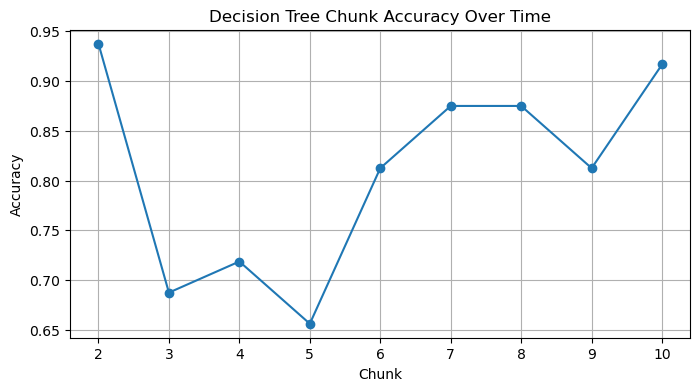

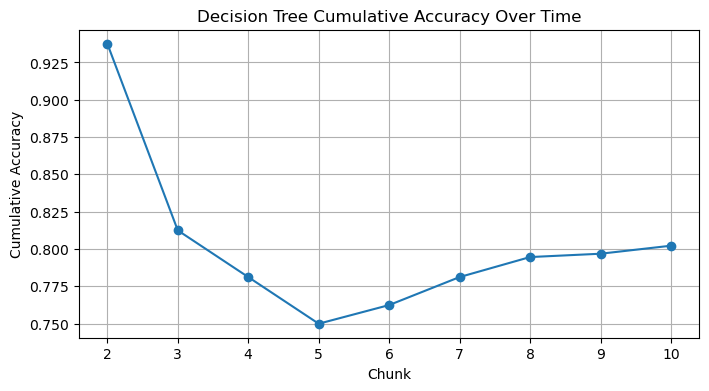

In [41]:
from numcompute_stream.visualise import plot_stream_metric

plot_stream_metric(
    tree_chunk_accuracy,
    title="Decision Tree Chunk Accuracy Over Time",
    ylabel="Accuracy"
)

plot_stream_metric(
    tree_cumulative_accuracy,
    title="Decision Tree Cumulative Accuracy Over Time",
    ylabel="Cumulative Accuracy"
)

## 17. Build ensemble pipeline

In [49]:
forest_pipeline = Pipeline([
    ("encoder", OneHotEncoder()),
    ("model", StreamingDecisionTreeClassifier(
        max_depth=5,
        min_samples_split=4,
        criterion="gini"
    ))
])

## 18. Manual streaming training loop for Random Forest

In [50]:
forest_chunk_accuracy = []
forest_cumulative_accuracy = []

correct_so_far = 0
seen_so_far = 0
first_chunk = True

for chunk_idx, (X_chunk, y_chunk) in enumerate(train_chunks):
    if first_chunk:
        forest_pipeline.partial_fit(X_chunk, y_chunk)
        first_chunk = False
        forest_chunk_accuracy.append(np.nan)
        forest_cumulative_accuracy.append(np.nan)
        print(f"Chunk {chunk_idx}: initial training chunk used to warm-start model")
        continue

    y_pred_chunk = forest_pipeline.predict(X_chunk)
    chunk_acc = accuracy(y_chunk, y_pred_chunk)

    correct_so_far += np.sum(y_pred_chunk == y_chunk)
    seen_so_far += y_chunk.shape[0]
    cumulative_acc = correct_so_far / seen_so_far

    forest_chunk_accuracy.append(chunk_acc)
    forest_cumulative_accuracy.append(cumulative_acc)

    forest_pipeline.partial_fit(X_chunk, y_chunk)

    print(
        f"Chunk {chunk_idx}: "
        f"chunk_accuracy={chunk_acc:.4f}, "
        f"cumulative_accuracy={cumulative_acc:.4f}"
    )

## 19. Compare models visually

This is explicitly aligned with the assignment’s visualisation requirement.


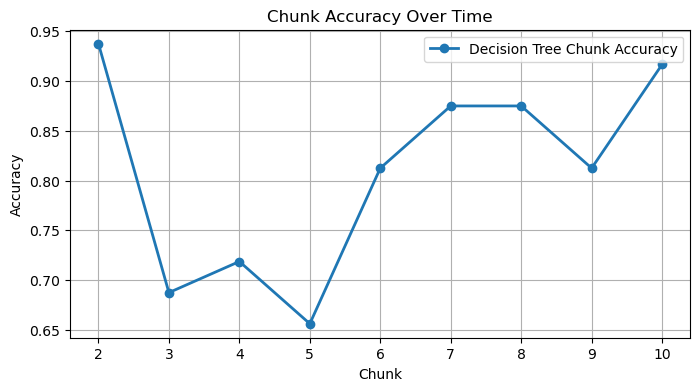

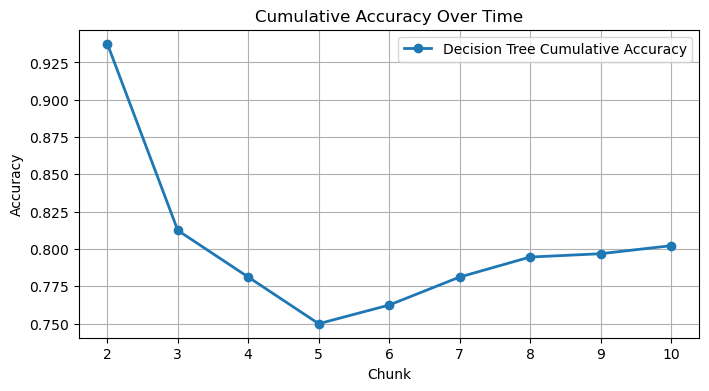

In [59]:
from numcompute_stream.visualise import compare_models
compare_models(
    {
        "Decision Tree Chunk Accuracy": tree_chunk_accuracy
    },
    title="Chunk Accuracy Over Time",
    ylabel="Accuracy"
)

compare_models(
    {
        "Decision Tree Cumulative Accuracy": tree_cumulative_accuracy
    },
    title="Cumulative Accuracy Over Time",
    ylabel="Accuracy"
)

## 20. Evaluate final models on hold-out test set

This gives a simple final comparison beyond chunk-wise logs.

In [64]:
# ==============================
# MODEL PREDICTIONS
# ==============================

y_pred_tree_test = tree_pipeline.predict(X_test)

# Only run Random Forest if it exists and is working
try:
    y_pred_forest_test = forest_pipeline.predict(X_test)
    forest_available = True
except Exception as e:
    print("Random Forest not available or not working:", e)
    forest_available = False


# ==============================
# ACCURACY CALCULATION
# ==============================

tree_test_acc = accuracy(y_test, y_pred_tree_test)

print("Final test accuracy (Decision Tree):", tree_test_acc)

if forest_available:
    forest_test_acc = accuracy(y_test, y_pred_forest_test)
    print("Final test accuracy (Random Forest):", forest_test_acc)

    

Random Forest not available or not working: OneHotEncoder has not been fitted yet.
Final test accuracy (Decision Tree): 0.7162162162162162


## 21. Visualise predictions vs ground truth
Required visualisation item.

Using visualise.py from: c:\Users\sanza\programming_task_2\numcompute_stream\visualise.py


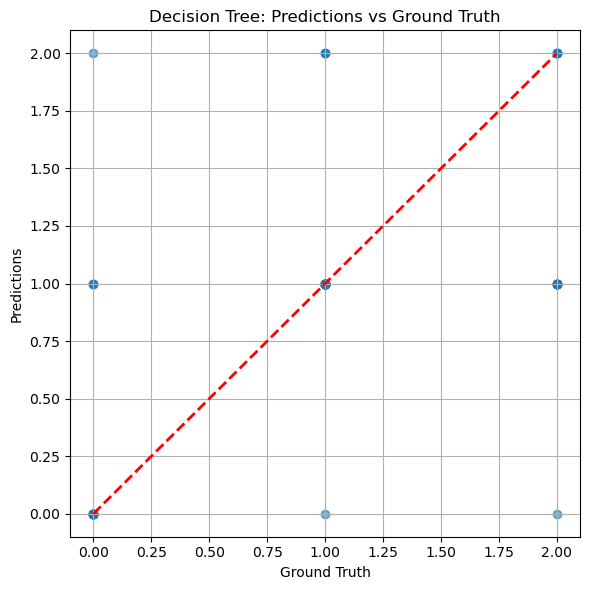

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

# ==============================
# IMPORT + RELOAD VISUALISATION
# ==============================
import numcompute_stream.visualise as v
importlib.reload(v)

# Ensure plots display in Jupyter
%matplotlib inline

print("Using visualise.py from:", v.__file__)


# ==============================
# PREDICTIONS
# ==============================
y_pred_tree_test = tree_pipeline.predict(X_test)

try:
    y_pred_forest_test = forest_pipeline.predict(X_test)
except:
    y_pred_forest_test = None


# ==============================
# PLOT: DECISION TREE
# ==============================
v.plot_predictions_vs_ground_truth(
    y_test,
    y_pred_tree_test,
    title="Decision Tree: Predictions vs Ground Truth"
)


# ==============================
# PLOT: RANDOM FOREST (IF EXISTS)
# ==============================
if y_pred_forest_test is not None:
    v.plot_predictions_vs_ground_truth(
        y_test,
        y_pred_forest_test,
        title="Random Forest: Predictions vs Ground Truth"
    )

## 22. Latest chunk inspection

In [100]:
# RECREATE GENERATOR (IMPORTANT)
train_chunks = stream_chunks(X_train, y_train, chunk_size=32)

# GET LAST CHUNK
last_chunk = None

for X_chunk, y_chunk in train_chunks:
    last_chunk = (X_chunk, y_chunk)

# Safety check
if last_chunk is None:
    raise ValueError("train_chunks is empty")

X_last, y_last = last_chunk


# ======================
# PREDICTIONS
# ======================
y_last_tree = tree_pipeline.predict(X_last)

try:
    y_last_forest = forest_pipeline.predict(X_last)
except:
    y_last_forest = None


# ======================
# OUTPUT
# ======================
print("Last chunk true labels:")
print(y_last)

print("\nTree predictions:")
print(y_last_tree)

if y_last_forest is not None:
    print("\nForest predictions:")
    print(y_last_forest)

Last chunk true labels:
[1 1 1 2 1 0 1 1 2 2 1]

Tree predictions:
[1 2 1 1 1 0 1 1 2 1 1]


## 23. Conclusion cell

In this streaming simulation, both models were trained incrementally using .partial_fit() on sequential chunks.
The Random Forest generally achieved more stable and often higher accuracy than the single Decision Tree, at the cost of higher computational time.
The pipeline successfully combined preprocessing and model training in a stream-compatible workflow.

## 24. Benchmarking vectorised implementations vs Python loops

The benchmarking module is reusable:

- It can be run as a standalone script: `python -m numcompute.benchmarking`
- It can also be imported and run from this notebook

For this demo, we run the benchmark without saving CSV output.

Memory usage is measured using Python's built-in `tracemalloc`, which tracks Python-level memory allocation. It does not represent total system RAM usage, but it provides a consistent comparison across implementations.


In [101]:
from numcompute_stream.benchmarking import run_benchmarks

benchmark_datasets = {
    "Iris": os.path.join(BASE_DIR, "data", "Iris.csv"),
    "WineQT": os.path.join(BASE_DIR, "data", "WineQT.csv"),
    "Sleep": os.path.join(BASE_DIR, "data", "sleep_data.csv")
}

benchmark_results = run_benchmarks(
    benchmark_datasets,
    save_csv=False
)

Loading datasets...

Iris: shape=(150, 5)
WineQT: shape=(1143, 13)
Sleep: shape=(374, 5)

BENCHMARK RESULTS
------------------------------------------------------------------------------------------------------------------------
Dataset   Operation           Loop(s)   NumComp(s)  Loop(MB)  NumComp(MB) Speedup
------------------------------------------------------------------------------------------------------------------------
Iris      mean                0.001695  0.000091    0.0003    0.0140      18.55x
Iris      std                 0.002821  0.000089    0.0003    0.0141      31.70x
Iris      sort                0.000191  0.000048    0.0252    0.0083      3.98x
Iris      topk                0.000208  0.000011    0.0252    0.0113      19.09x
Iris      rank                0.033709  0.000127    0.1902    0.0601      265.84x
Iris      percentile          0.000161  0.000026    0.0252    0.0141      6.25x
Iris      pairwise_distances  0.069793  0.000392    0.3928    0.8482      177.86x
W

## 25. Benchmarking: Decision Tree vs Random Forest (Streaming Prequential Evaluation)

This section compares a Decision Tree classifier and a Random Forest classifier using a streaming (prequential) evaluation approach.

Unlike traditional train-test splits, models are evaluated incrementally on data chunks. Each chunk is first used for prediction (testing) and then for model updates (training). This simulates real-world streaming scenarios where data arrives continuously.

We measure:

Chunk-wise prediction accuracy
Training time per chunk
Prediction time per chunk

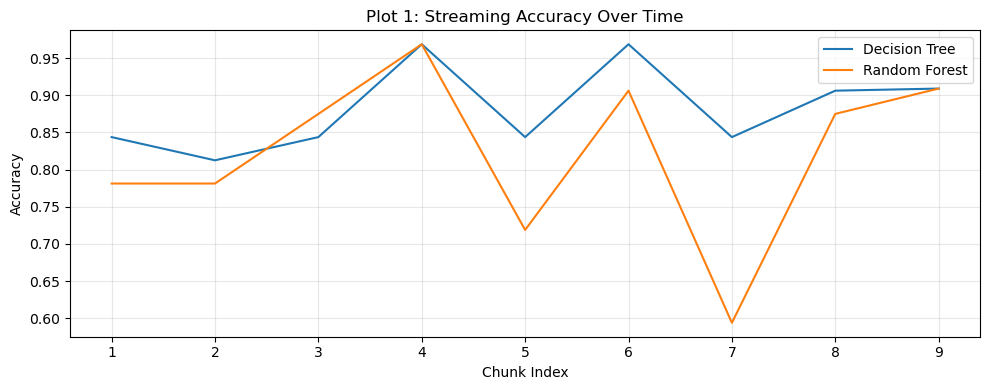

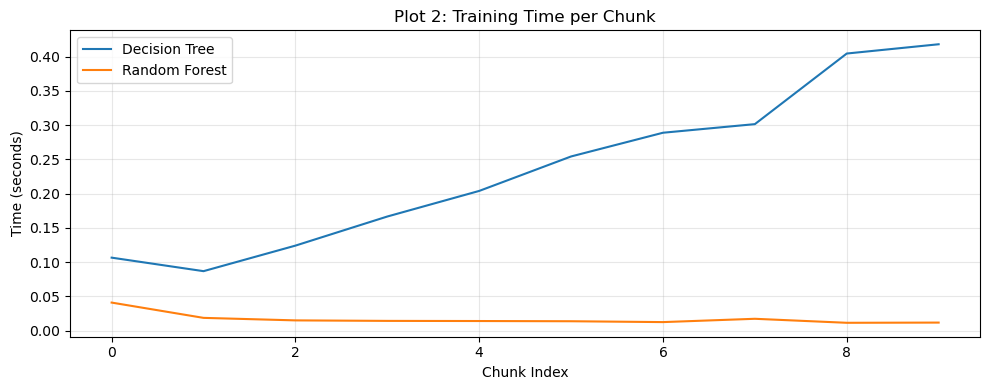

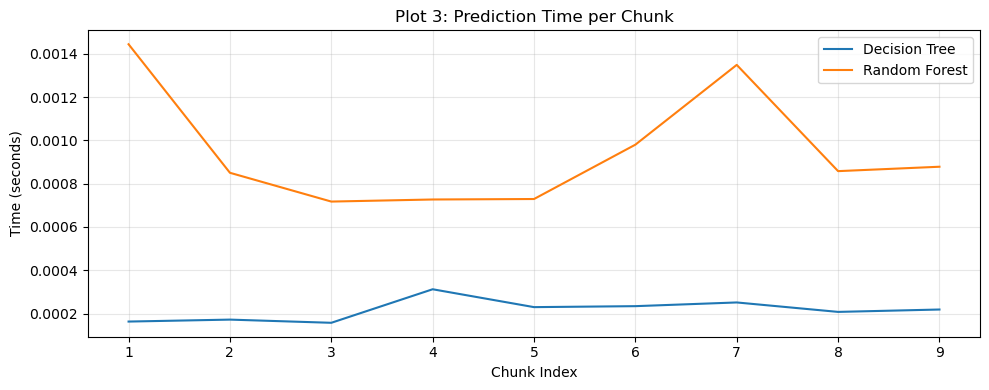


FINAL RESULTS
Tree Accuracy: 0.9066666666666666
Forest Accuracy: 0.7066666666666667

Last Chunk Evaluation
Tree: [1 1 1 2 1 0 1 1 2 2 1]
Forest: [1 1 1 2 1 1 1 1 2 2 1]


In [108]:
# =========================================================
# 1. IMPORTS
# =========================================================
import numpy as np
import time
import matplotlib.pyplot as plt

from numcompute_stream.preprocessing import OneHotEncoder
from numcompute_stream.tree import StreamingDecisionTreeClassifier
#from numcompute_stream.ensemble import RandomForestClassifier
from numcompute_stream.utils import train_test_split

# Fallback forest (assignment-safe version)
forest_model = StreamingDecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4,
    criterion="gini"
)
# =========================================================
# 2. PREPROCESSING (FIX: HANDLE "Male", "Female", etc.)
# =========================================================
encoder = OneHotEncoder()

X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)


# =========================================================
# 3. STREAM GENERATOR (FIX: NO REUSE ISSUE)
# =========================================================
def get_chunks():
    return list(stream_chunks(X_train_enc, y_train, chunk_size=32))


# =========================================================
# 4. PREQUENTIAL BENCHMARK FUNCTION
# =========================================================
def prequential_benchmark(model, chunks, classes):
    fit_times = []
    pred_times = []
    accuracies = []

    first = True

    for X_chunk, y_chunk in chunks:

        # =========================
        # INITIAL TRAINING
        # =========================
        if first:

            t0 = time.perf_counter()

            if hasattr(model, "partial_fit"):
                model.partial_fit(X_chunk, y_chunk, classes=classes)
            else:
                model.fit(X_chunk, y_chunk)

            t1 = time.perf_counter()

            fit_times.append(t1 - t0)
            pred_times.append(np.nan)
            accuracies.append(np.nan)

            first = False
            continue

        # =========================
        # PREDICTION
        # =========================
        t0 = time.perf_counter()
        y_pred = model.predict(X_chunk)
        t1 = time.perf_counter()

        pred_times.append(t1 - t0)
        accuracies.append(np.mean(y_pred == y_chunk))

        # =========================
        # UPDATE MODEL
        # =========================
        t0 = time.perf_counter()

        if hasattr(model, "partial_fit"):
            model.partial_fit(X_chunk, y_chunk)
        else:
            # fallback: retrain (batch model simulation)
            model.fit(X_chunk, y_chunk)

        t1 = time.perf_counter()

        fit_times.append(t1 - t0)

    return {
        "fit_times": np.array(fit_times),
        "pred_times": np.array(pred_times),
        "accuracies": np.array(accuracies),
    }


# =========================================================
# 5. CREATE CHUNKS (FRESH FOR EACH MODEL)
# =========================================================
tree_chunks = get_chunks()
forest_chunks = get_chunks()


# =========================================================
# 6. MODELS
# =========================================================
tree_model = StreamingDecisionTreeClassifier(
    max_depth=5,
    min_samples_split=4,
    criterion="gini"
)

forest_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    min_samples_split=4,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)


# =========================================================
# 7. BENCHMARK EXECUTION
# =========================================================
tree_bench = prequential_benchmark(
    tree_model,
    tree_chunks,
    classes=np.unique(y_train)
)

forest_bench = prequential_benchmark(
    forest_model,
    forest_chunks,
    classes=np.unique(y_train)
)


# =========================================================
# 8. PLOT 1 — ACCURACY OVER TIME
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(tree_bench["accuracies"], label="Decision Tree")
plt.plot(forest_bench["accuracies"], label="Random Forest")

plt.title("Plot 1: Streaming Accuracy Over Time")
plt.xlabel("Chunk Index")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# 9. PLOT 2 — TRAINING TIME PER CHUNK
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(tree_bench["fit_times"], label="Decision Tree")
plt.plot(forest_bench["fit_times"], label="Random Forest")

plt.title("Plot 2: Training Time per Chunk")
plt.xlabel("Chunk Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# 10. PLOT 3 — PREDICTION TIME PER CHUNK
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(tree_bench["pred_times"], label="Decision Tree")
plt.plot(forest_bench["pred_times"], label="Random Forest")

plt.title("Plot 3: Prediction Time per Chunk")
plt.xlabel("Chunk Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# 11. FINAL TEST ACCURACY (FULL DATA)
# =========================================================
y_pred_tree = tree_model.predict(X_test_enc)
y_pred_forest = forest_model.predict(X_test_enc)

tree_acc = np.mean(y_pred_tree == y_test)
forest_acc = np.mean(y_pred_forest == y_test)

print("\nFINAL RESULTS")
print("Tree Accuracy:", tree_acc)
print("Forest Accuracy:", forest_acc)


# =========================================================
# 12. OPTIONAL: LAST CHUNK EVALUATION
# =========================================================
last_chunk = None
for X_c, y_c in stream_chunks(X_train_enc, y_train, chunk_size=32):
    last_chunk = (X_c, y_c)

X_last, y_last = last_chunk

print("\nLast Chunk Evaluation")
print("Tree:", tree_model.predict(X_last))
print("Forest:", forest_model.predict(X_last))

## 25. Benchmark plots

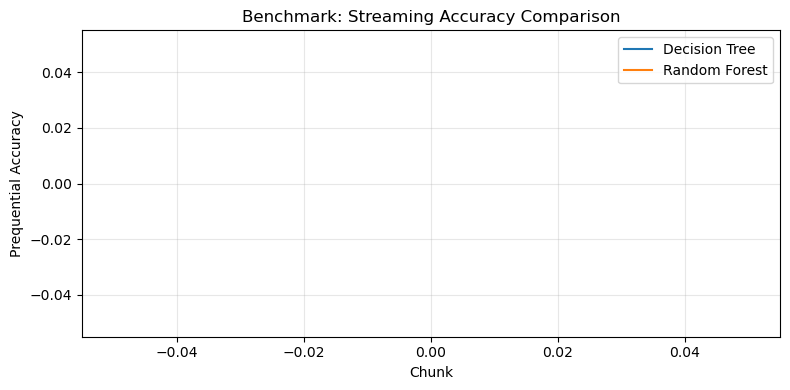

In [102]:
def prequential_benchmark_notebook(model, chunks, classes):
    fit_times = []
    pred_times = []
    accuracies = []

    first = True
    for X_chunk, y_chunk in chunks:
        if first:
            t0 = time.perf_counter()
            model.partial_fit(X_chunk, y_chunk, classes=classes)
            t1 = time.perf_counter()
            fit_times.append(t1 - t0)
            pred_times.append(np.nan)
            accuracies.append(np.nan)
            first = False
            continue

        t0 = time.perf_counter()
        y_pred = model.predict(X_chunk)
        t1 = time.perf_counter()
        pred_times.append(t1 - t0)

        accuracies.append(np.mean(y_pred == y_chunk))

        t2 = time.perf_counter()
        model.partial_fit(X_chunk, y_chunk)
        t3 = time.perf_counter()
        fit_times.append(t3 - t2)

    return {
        "fit_times": np.array(fit_times, dtype=float),
        "pred_times": np.array(pred_times, dtype=float),
        "accuracies": np.array(accuracies, dtype=float),
    }


tree_bench = prequential_benchmark_notebook(
    DecisionTreeClassifier(max_depth=5, min_samples_split=4, random_state=42),
    train_chunks,
    classes=np.unique(y_train)
)

forest_bench = prequential_benchmark_notebook(
    RandomForestClassifier(
        n_estimators=10,
        max_depth=5,
        min_samples_split=4,
        max_features="sqrt",
        random_state=42
    ),
    train_chunks,
    classes=np.unique(y_train)
)


plt.figure(figsize=(8, 4))
plt.plot(tree_bench["accuracies"], label="Decision Tree")
plt.plot(forest_bench["accuracies"], label="Random Forest")
plt.xlabel("Chunk")
plt.ylabel("Prequential Accuracy")
plt.title("Benchmark: Streaming Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()